In [1]:
import os
import torch
import matplotlib.pyplot as plt
import numpy as np
from utils import ResultLoader, plot_results_split

# 设置绘图风格
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 12,
    'figure.titlesize': 20
})

TITLE_FONT_SIZE = 32
LABEL_FONT_SIZE = 28
TICK_FONT_SIZE = 24
LEGEND_FONT_SIZE = 20
chart_color = '#2c7fb8' # 深蓝色

loader = ResultLoader("../results")

In [2]:
def load_parameter_stats(selected_group, experiments, common_args, loader, x_lim=200):
    """
    加载并计算实验数据的 Max Acc 均值和标准差。
    返回: param_values (x), means (y), stds, param_name
    """
    import numpy as np
    param_values = []
    means = []
    stds = []

    # 尝试从 label 中提取参数名
    param_name = "Parameter"
    if selected_group and '=' in selected_group[0]:
        param_name = selected_group[0].split('=')[0]

    for label in selected_group:
        if label not in experiments: continue
        algo_name, kwargs = experiments[label]
        merged_args = {**common_args, **kwargs}

        try:
            val = float(label.split('=')[1]) if '=' in label else float(label)
        except (IndexError, ValueError):
            val = label

        run_results = []
        idx = 0
        while True:
            data = loader.load(algo_name, **merged_args, specific_run=idx)
            if data is None: break
            run_results.append(data)
            idx += 1

        if not run_results: continue

        m_run_max = []
        for run in run_results:
            acc_data = run.get("acc", {})
            if isinstance(acc_data, dict):
                mk = next((k for k in ["model", "local"] if k in acc_data), None)
                if mk:
                    y_data = acc_data[mk][:x_lim]
                    if y_data: m_run_max.append(np.max(y_data))
            elif isinstance(acc_data, list):
                y_data = acc_data[:x_lim]
                if y_data: m_run_max.append(np.max(y_data))

        if m_run_max:
            param_values.append(val)
            means.append(np.mean(m_run_max))
            stds.append(np.std(m_run_max))

    # 排序
    if all(isinstance(v, (int, float)) for v in param_values):
        data_points = sorted(zip(param_values, means, stds), key=lambda x: x[0])
        param_values = [p[0] for p in data_points]
        means = [p[1] for p in data_points]
        stds = [p[2] for p in data_points]

    return param_values, means, stds, param_name


In [3]:
algo = 'feddpc'
# 显式定义模式
loader.algo_patterns[algo] = lambda args: f"_{args['lamda_']}_{args['head_epochs']}_{args['body_epochs']}_{args['lr_head']}_{args['lr_body']}_{args['server_epochs']}_{args['server_lr']}_{args['margin_threshold']}_{args['lambda_p']}_{args['lambda_acl']}"

common_args = {
    "dataset": "cifar10",
    "partition": "dirichlet",
    "alpha": 0.1,
    "num_clients": 10,
    "model": "cnn",
    "epochs": 1,
    "batch_size": 64,
    "lr": 0.01,
    "n_class": 0,
    "times": 5
}

experiments = {}
base_conf = {
    "lamda_": 100.0,
    "lambda_p": 1.0,
    "lambda_acl": 0.01,
    "head_epochs": 10,
    "body_epochs": 1,
    "lr_head": 0.01,
    "lr_body": 0.01,
    "margin_threshold": 100.0,
    "server_epochs": 100,
    "server_lr": 0.01
}

In [4]:
be_list = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
be_labels = []
for be in be_list:
    label = f"head_epochs={be}"
    conf = base_conf.copy()
    conf["head_epochs"] = be
    experiments[label] = (algo, conf)
    be_labels.append(label)

x, y, std, param_name = load_parameter_stats(be_labels, experiments, common_args, loader)

图表已保存为文件: figures/model_accuracy.pdf


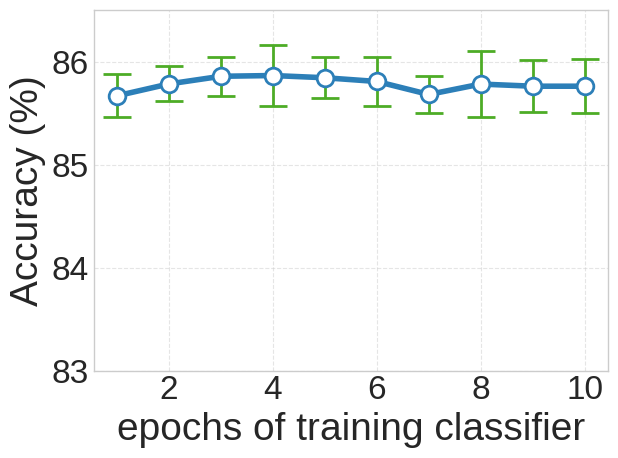

In [8]:
plt.figure()
plt.errorbar(x, y, yerr=std,
             color=chart_color, # 设置线条和标记的颜色
             marker='o',
             markersize=12, # 增大标记大小，使其与 linewidth 协调
             markerfacecolor='white', # 设置标记内部颜色为白色，使边界更清晰
             markeredgecolor=chart_color, # 设置标记边界颜色
             markeredgewidth=2, # 设置标记边界线宽
             linewidth=4,
             capsize=10,
             elinewidth=2,
             ecolor='#4dac26', # 为误差棒单独设置一种颜色，使其与线条区分开
             label='Model Acc')

# 标签和标题
plt.xlabel('epochs of training classifier', fontsize=LABEL_FONT_SIZE)
plt.ylabel("Accuracy (%)", fontsize=LABEL_FONT_SIZE)

# 网格
plt.grid(True, linestyle='--', alpha=0.5) # 使用虚线网格，并降低透明度，使其更细致

# 遵守用户提供的数据范围
plt.ylim(83.5, 86.5)
plt.xticks(fontsize=TICK_FONT_SIZE)
plt.yticks(np.arange(83, 87, 1), fontsize=TICK_FONT_SIZE)

# 确保布局紧凑，防止标签被切断
plt.tight_layout()

# 保存文件
file_name = 'figures/model_accuracy.pdf'
plt.savefig(file_name, format='pdf', bbox_inches='tight')
print(f"图表已保存为文件: {file_name}")

# 显示图表
plt.show()